# 05_dimensionality_reduction

Comparison of dimensionality reduction techniques applied to Planet SuperDove band statistics
and circular patch features for turbidity estimation.

**Inputs** (from `04_feature_engineering`):
- `data/processed/feature_engineering/fe_tabular.parquet` — 45 features, 200 m buffer stats
- `data/processed/feature_engineering/fe_{N}px_stats.parquet` — band stats per patch size
- `data/processed/feature_engineering/fe_{N}px_texture.parquet` — stats + texture (69 features)
- `data/processed/feature_engineering/fe_{N}px_pca.parquet` — PCA-reduced pixel vectors

**Methods benchmarked:**

| # | Method | Type |
|---|--------|------|
| 0 | No reduction (baseline) | — |
| 1 | Variance threshold + correlation filter | Filter |
| 2 | PCA | Linear |
| 3 | Kernel PCA (RBF / poly) | Non-linear |
| 4 | Incremental PCA / TruncatedSVD | Linear (large) |
| 5 | UMAP | Non-linear manifold |
| 6 | Autoencoder (MLP, PyTorch) | Neural |
| 7 | RFECV (Random Forest) | Wrapper |

**Evaluation:** GroupKFold (group = `ctd`) to prevent station-level data leakage.  
**Models:** Ridge regression and Random Forest regressor.  
**Metrics:** RMSE, MAE, R².

---
## 1 · Setup & Load Feature Datasets

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from itertools import product

from sklearn.base import clone
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA, TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Paths
FE_DIR   = Path("../data/processed/feature_engineering")
META_COLS = ["ctd", "date", "turbidity"]

# ── Load all available feature datasets ─────────────────────────────────────
datasets = {}
for f in sorted(FE_DIR.glob("*.parquet")):
    df = pd.read_parquet(f)
    df["date"] = pd.to_datetime(df["date"]).dt.date
    df["ctd"]  = df["ctd"].astype(str)
    df["turbidity"] = pd.to_numeric(df["turbidity"], errors="coerce")
    df = df.dropna(subset=["turbidity"])
    datasets[f.stem] = df

print(f"Loaded {len(datasets)} datasets:")
for name, df in datasets.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    print(f"  {name:40s}  N={len(df):4d}  features={len(feat_cols)}")

Loaded 16 datasets:
  fe_128px_pca                              N= 415  features=12
  fe_128px_stats                            N= 415  features=45
  fe_128px_texture                          N= 415  features=69
  fe_16px_pca                               N= 415  features=1
  fe_16px_stats                             N= 415  features=45
  fe_16px_texture                           N= 415  features=69
  fe_256px_pca                              N= 415  features=19
  fe_256px_stats                            N= 415  features=45
  fe_256px_texture                          N= 415  features=69
  fe_32px_pca                               N= 415  features=1
  fe_32px_stats                             N= 415  features=45
  fe_32px_texture                           N= 415  features=69
  fe_64px_pca                               N= 415  features=8
  fe_64px_stats                             N= 415  features=45
  fe_64px_texture                           N= 415  features=69
  fe_tabular           

In [2]:
def get_Xy(df: pd.DataFrame):
    """Split a feature dataset into X (scaled), y, and groups (ctd)."""
    feat_cols = [c for c in df.columns if c not in META_COLS]
    X_raw = df[feat_cols].values.astype(np.float32)
    y     = df["turbidity"].values.astype(np.float32)
    groups = df["ctd"].values
    # Drop columns that are entirely NaN, then impute remaining NaN with column mean
    col_mask = ~np.all(np.isnan(X_raw), axis=0)
    X_raw    = X_raw[:, col_mask]
    col_means = np.nanmean(X_raw, axis=0)
    nan_mask  = np.isnan(X_raw)
    X_raw[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    scaler = StandardScaler()
    X      = scaler.fit_transform(X_raw)
    return X, y, groups, [feat_cols[i] for i in range(len(feat_cols)) if col_mask[i]]


def cv_scores(X, y, groups, model, n_splits=5):
    """Return mean RMSE, CV_RMSE, MAE, R² over GroupKFold splits.
    CV_RMSE = RMSE / mean(y_test) — normalized RMSE by test mean.
    A fresh clone of the model is fitted in each fold."""
    from sklearn.base import clone as _clone
    gkf = GroupKFold(n_splits=min(n_splits, len(np.unique(groups))))
    rmse_list, cv_rmse_list, mae_list, r2_list = [], [], [], []
    for tr, te in gkf.split(X, y, groups):
        m = _clone(model)
        m.fit(X[tr], y[tr])
        pred = m.predict(X[te])
        mse = mean_squared_error(y[te], pred)
        rmse = np.sqrt(mse)
        y_test_mean = np.mean(y[te])
        cv_rmse = rmse / y_test_mean if y_test_mean > 0 else np.nan
        rmse_list.append(rmse)
        cv_rmse_list.append(cv_rmse)
        mae_list.append(mean_absolute_error(y[te], pred))
        r2_list.append(r2_score(y[te], pred))
    return np.mean(rmse_list), np.mean(cv_rmse_list), np.mean(mae_list), np.mean(r2_list)


MODELS = {
    "Ridge":         Ridge(alpha=1.0),
    "RandomForest":  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

# Master results list
all_results = []

print("Helpers defined. MODELS:", list(MODELS.keys()))


Helpers defined. MODELS: ['Ridge', 'RandomForest']


---
## 2 · Baseline: No Dimensionality Reduction

Train Ridge and Random Forest on `fe_tabular` and `fe_64px_texture` with raw (scaled) features.
GroupKFold on CTD station prevents data leakage across sampling locations.

In [3]:
BASELINE_DATASETS = ["fe_tabular", "fe_64px_texture"]

for ds_name in BASELINE_DATASETS:
    if ds_name not in datasets:
        print(f"  {ds_name} not found, skipping"); continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    print(f"\n{ds_name}  ({X.shape[1]} features, N={len(y)})")
    for model_name, model in MODELS.items():
        import sklearn; sklearn.clone  # ensure fresh model each loop
        from sklearn.base import clone
        rmse, cv_rmse, mae, r2 = cv_scores(X, y, groups, clone(model))
        print(f"  {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
        all_results.append({
            "method": "Baseline",
            "dataset": ds_name,
            "model": model_name,
            "n_components": X.shape[1],
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })


fe_tabular  (45 features, N=419)
  Ridge            RMSE=1.1937  CV_RMSE=0.8800  MAE=0.7006  R²=0.0589
  RandomForest     RMSE=1.0615  CV_RMSE=0.7887  MAE=0.6421  R²=0.2375

fe_64px_texture  (69 features, N=415)
  Ridge            RMSE=1.2096  CV_RMSE=0.8689  MAE=0.7321  R²=0.0083
  RandomForest     RMSE=1.1455  CV_RMSE=0.8245  MAE=0.7064  R²=0.1048


---
## 3 · Filter Methods: Variance Threshold + Correlation Filter

1. Drop features whose variance falls below a threshold (near-constant across samples).
2. Among remaining features, iteratively drop one of each pair with |Pearson r| > 0.95.

In [4]:
from sklearn.base import clone

def variance_correlation_filter(X: np.ndarray, var_threshold: float = 0.01,
                                  corr_threshold: float = 0.95):
    """Return boolean column mask after variance + correlation filtering."""
    # Step 1: variance threshold
    vt = VarianceThreshold(threshold=var_threshold)
    vt.fit(X)
    mask = vt.get_support()

    # Step 2: drop highly-correlated pairs
    X_vt = X[:, mask]
    corr_matrix = np.corrcoef(X_vt.T)
    np.fill_diagonal(corr_matrix, 0)
    drop_idx = set()
    for i in range(corr_matrix.shape[0]):
        if i in drop_idx:
            continue
        for j in range(i + 1, corr_matrix.shape[1]):
            if abs(corr_matrix[i, j]) > corr_threshold:
                drop_idx.add(j)

    keep_idx = [i for i in range(X_vt.shape[1]) if i not in drop_idx]
    return X_vt[:, keep_idx], len(keep_idx)


print(f"{'Dataset':40s}  {'Raw':>5}  {'After filter':>12}")
for ds_name in BASELINE_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    X_filt, n_kept = variance_correlation_filter(X)
    print(f"{ds_name:40s}  {X.shape[1]:>5}  {n_kept:>12}")

    for model_name, model in MODELS.items():
        rmse, cv_rmse, mae, r2 = cv_scores(X_filt, y, groups, clone(model))
        print(f"    {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
        all_results.append({
            "method": "VarThresh+Corr",
            "dataset": ds_name,
            "model": model_name,
            "n_components": n_kept,
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })

Dataset                                     Raw  After filter
fe_tabular                                   45            10
    Ridge            RMSE=1.1888  CV_RMSE=0.8754  MAE=0.7012  R²=0.0689
    RandomForest     RMSE=1.1264  CV_RMSE=0.8337  MAE=0.6820  R²=0.1533
fe_64px_texture                              69            20
    Ridge            RMSE=1.2004  CV_RMSE=0.8632  MAE=0.7255  R²=0.0169
    RandomForest     RMSE=1.1841  CV_RMSE=0.8520  MAE=0.7275  R²=0.0436


---
## 4 · PCA (Principal Component Analysis)

Linear projection maximising variance. We sweep `n_components` and plot cumulative explained
variance curves plus RMSE vs. number of components for Ridge and Random Forest.

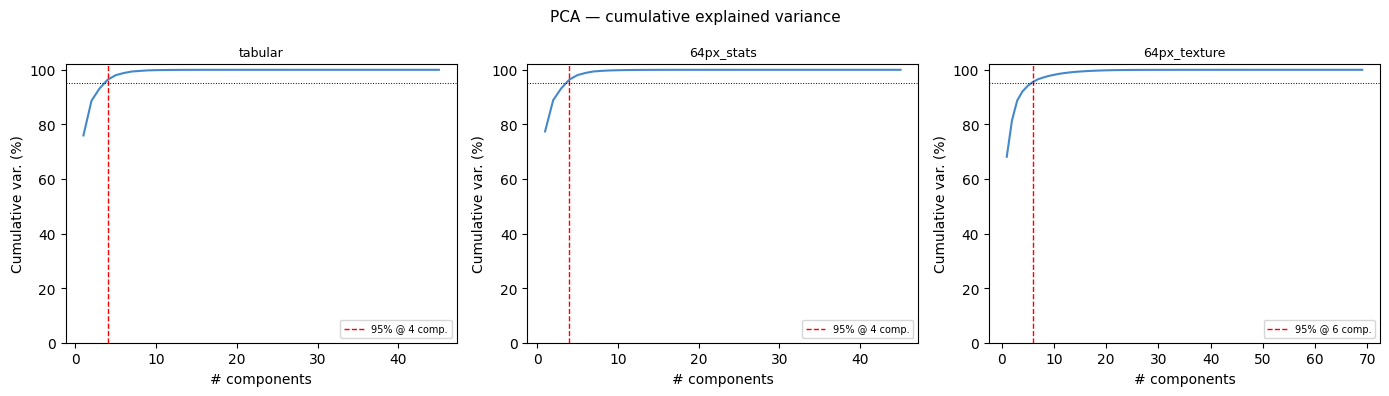

In [5]:
PCA_DATASETS = ["fe_tabular", "fe_64px_stats", "fe_64px_texture"]
PCA_COMP_SWEEP = [2, 4, 6, 8, 10, 15, 20, 30]

fig, axes = plt.subplots(1, len(PCA_DATASETS), figsize=(14, 4))
fig.suptitle("PCA — cumulative explained variance", fontsize=11)

for ax, ds_name in zip(axes, PCA_DATASETS):
    if ds_name not in datasets:
        ax.set_title(f"{ds_name}\n(not found)"); ax.axis("off"); continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    max_comp = min(X.shape[1], X.shape[0] - 1)
    pca_full = PCA(n_components=max_comp, random_state=42).fit(X)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_) * 100
    ax.plot(range(1, len(cumvar) + 1), cumvar, lw=1.5, color="#4488cc")
    elbow = int(np.searchsorted(cumvar, 95)) + 1
    ax.axvline(elbow, color="red", lw=1, ls="--", label=f"95% @ {elbow} comp.")
    ax.axhline(95, color="black", lw=0.7, ls=":")
    ax.set_xlabel("# components"); ax.set_ylabel("Cumulative var. (%)")
    ax.set_title(ds_name.replace("fe_", ""), fontsize=9)
    ax.legend(fontsize=7); ax.set_ylim(0, 102)

plt.tight_layout()
plt.show()

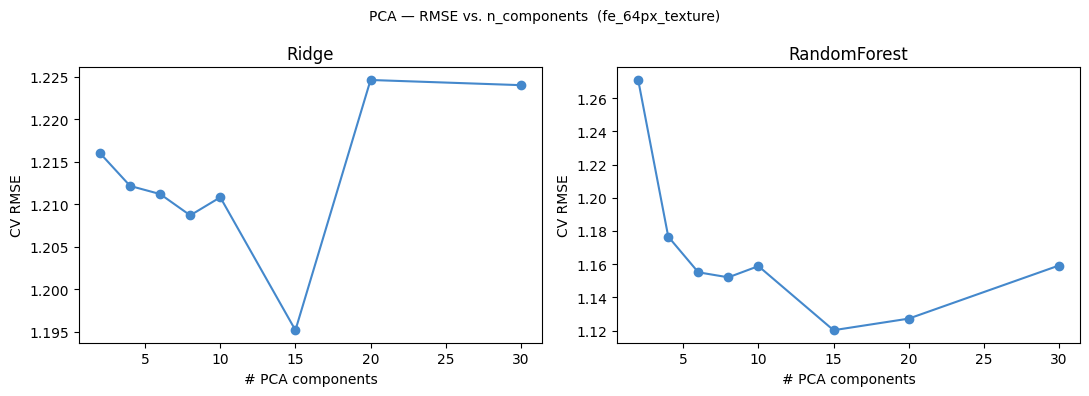

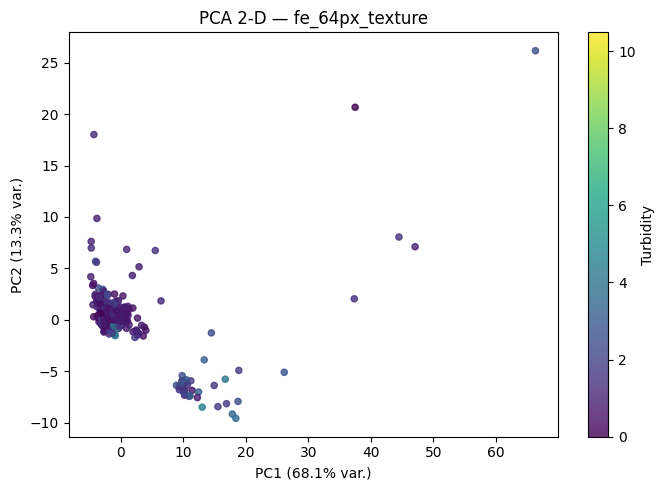

In [6]:
# RMSE sweep over n_components for the reference dataset
ref_ds = "fe_64px_texture"
if ref_ds in datasets:
    X, y, groups, _ = get_Xy(datasets[ref_ds])
    sweep_comps = [c for c in PCA_COMP_SWEEP if c < min(X.shape[0], X.shape[1])]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f"PCA — RMSE vs. n_components  ({ref_ds})", fontsize=10)

    for ax, (model_name, model) in zip(axes, MODELS.items()):
        rmse_vals = []
        for n in sweep_comps:
            pca   = PCA(n_components=n, random_state=42)
            X_pca = pca.fit_transform(X)
            rmse, cv_rmse, _, _ = cv_scores(X_pca, y, groups, clone(model))
            rmse_vals.append(rmse)
            all_results.append({
                "method": f"PCA",
                "dataset": ref_ds,
                "model": model_name,
                "n_components": n,
                "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": np.nan, "R2": np.nan,
            })
        ax.plot(sweep_comps, rmse_vals, marker="o", color="#4488cc", lw=1.5)
        ax.set_xlabel("# PCA components"); ax.set_ylabel("CV RMSE")
        ax.set_title(model_name)
    plt.tight_layout(); plt.show()

# 2-D scatter coloured by turbidity
if ref_ds in datasets:
    X, y, groups, _ = get_Xy(datasets[ref_ds])
    pca2 = PCA(n_components=2, random_state=42)
    Z    = pca2.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="viridis", s=20, alpha=0.8)
    plt.colorbar(sc, ax=ax, label="Turbidity")
    ax.set_xlabel(f"PC1 ({100*pca2.explained_variance_ratio_[0]:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({100*pca2.explained_variance_ratio_[1]:.1f}% var.)")
    ax.set_title(f"PCA 2-D — {ref_ds}"); plt.tight_layout(); plt.show()

---
## 5 · Kernel PCA

Non-linear generalisation of PCA using the kernel trick. RBF and polynomial kernels are
tested on `fe_tabular` and `fe_64px_stats`. A small grid-search over gamma and n_components
is run; Ridge regression is used as the downstream model.

In [7]:
KPCA_DATASETS = ["fe_tabular", "fe_64px_stats"]
KPCA_CONFIGS  = [
    {"kernel": "rbf",  "gamma": 0.01,  "n_components": 10},
    {"kernel": "rbf",  "gamma": 0.1,   "n_components": 10},
    {"kernel": "rbf",  "gamma": 1.0,   "n_components": 10},
    {"kernel": "poly", "gamma": 0.01,  "n_components": 10},
]

print(f"{'Dataset':30s}  {'Kernel':6s}  {'gamma':6s}  {'n':>3}  RMSE (Ridge)")
for ds_name in KPCA_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, _ = get_Xy(datasets[ds_name])
    best_rmse, best_cfg = np.inf, None
    for cfg in KPCA_CONFIGS:
        try:
            kpca  = KernelPCA(n_components=cfg["n_components"],
                              kernel=cfg["kernel"],
                              gamma=cfg["gamma"],
                              random_state=42)
            X_k   = kpca.fit_transform(X)
            # If KernelPCA produces NaN (zero variance components), skip
            if np.any(np.isnan(X_k)) or np.any(np.isinf(X_k)):
                continue
            X_k   = StandardScaler().fit_transform(X_k)
            rmse, cv_rmse, mae, r2 = cv_scores(X_k, y, groups, clone(MODELS["Ridge"]))
            lbl   = f"{cfg['kernel']}/{cfg['gamma']}"
            print(f"  {ds_name:28s}  {cfg['kernel']:6s}  {cfg['gamma']:6.2f}  "
                  f"{cfg['n_components']:>3}  {rmse:.4f}")
            if rmse < best_rmse:
                best_rmse = rmse; best_cfg = cfg
            all_results.append({
                "method": f"KernelPCA ({cfg['kernel']} g={cfg['gamma']})",
                "dataset": ds_name, "model": "Ridge",
                "n_components": cfg["n_components"],
                "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
            })
        except Exception as e:
            print(f"  {ds_name} {cfg}: skipped ({e})")
    if best_cfg:
        print(f"  → Best for {ds_name}: kernel={best_cfg['kernel']} "
              f"gamma={best_cfg['gamma']}  RMSE={best_rmse:.4f}\n")

Dataset                         Kernel  gamma     n  RMSE (Ridge)
  fe_tabular                    rbf       0.01   10  1.1982
  fe_tabular                    rbf       0.10   10  1.1869
  fe_tabular                    rbf       1.00   10  1.1868
  fe_tabular                    poly      0.01   10  2.0162
  → Best for fe_tabular: kernel=rbf gamma=1.0  RMSE=1.1868

  fe_64px_stats                 rbf       0.01   10  1.2065
  fe_64px_stats                 rbf       0.10   10  1.1812
  fe_64px_stats                 rbf       1.00   10  1.1885
  fe_64px_stats                 poly      0.01   10  1.2392
  → Best for fe_64px_stats: kernel=rbf gamma=0.1  RMSE=1.1812



---
## 6 · Incremental PCA / TruncatedSVD for Large Patch Sizes

`fe_128px_texture` and `fe_256px_texture` may have many more features.
`IncrementalPCA` processes data in mini-batches (memory-efficient). `TruncatedSVD` works
directly on the raw (uncentred) matrix and is a good fallback for sparse or very wide data.

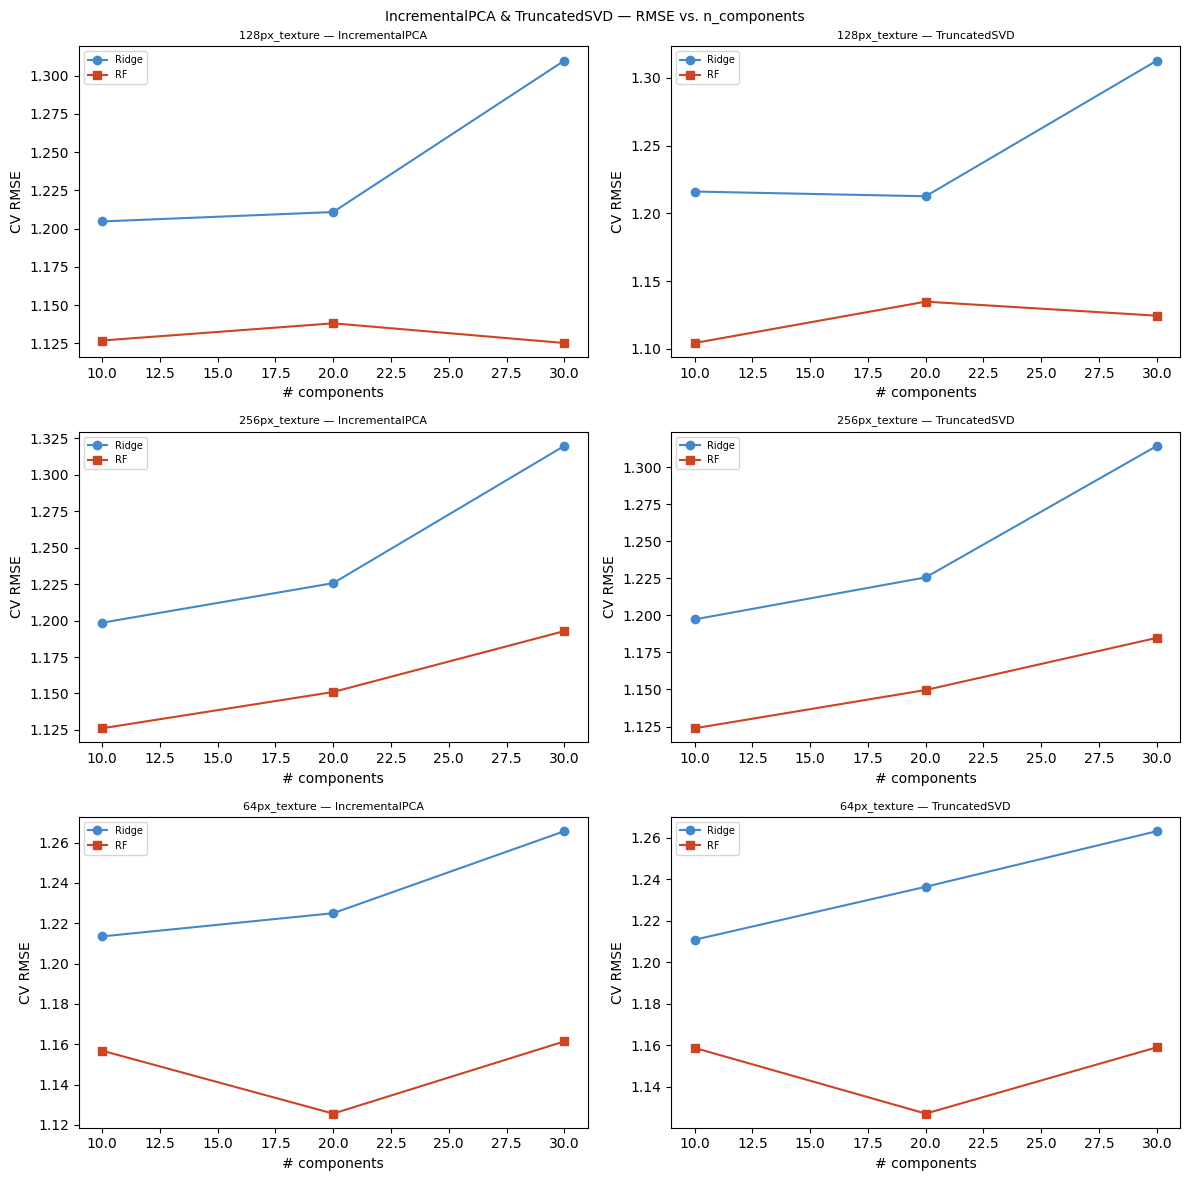

In [8]:
LARGE_DATASETS = ["fe_128px_texture", "fe_256px_texture", "fe_64px_texture"]
IPCA_COMPS     = [10, 20, 30]

fig_rows = len(LARGE_DATASETS)
fig, axes = plt.subplots(fig_rows, 2, figsize=(12, 4 * max(fig_rows, 1)), squeeze=False)
fig.suptitle("IncrementalPCA & TruncatedSVD — RMSE vs. n_components", fontsize=10)

for row_idx, ds_name in enumerate(LARGE_DATASETS):
    if ds_name not in datasets:
        for ax in axes[row_idx]:
            ax.set_title(f"{ds_name}\n(not found)"); ax.axis("off")
        continue

    X, y, groups, _ = get_Xy(datasets[ds_name])
    comps = [c for c in IPCA_COMPS if c < min(X.shape[0] - 1, X.shape[1])]

    for col_idx, (Reducer, label) in enumerate(
        [(IncrementalPCA, "IncrementalPCA"), (TruncatedSVD, "TruncatedSVD")]
    ):
        ax   = axes[row_idx][col_idx]
        rmse_ridge = []
        rmse_rf    = []

        for n in comps:
            reducer = Reducer(n_components=n)
            X_red   = reducer.fit_transform(X)
            X_red   = StandardScaler().fit_transform(X_red)
            for m_name, model in MODELS.items():
                rmse, cv_rmse, mae, r2 = cv_scores(X_red, y, groups, clone(model))
                all_results.append({
                    "method": label,
                    "dataset": ds_name, "model": m_name,
                    "n_components": n,
                    "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
                })
                if m_name == "Ridge":
                    rmse_ridge.append(rmse)
                else:
                    rmse_rf.append(rmse)

        ax.plot(comps, rmse_ridge, marker="o", label="Ridge", color="#4488cc")
        ax.plot(comps, rmse_rf,    marker="s", label="RF",    color="#cc4422")
        ax.set_xlabel("# components"); ax.set_ylabel("CV RMSE")
        ax.set_title(f"{ds_name.replace('fe_','')} — {label}", fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

---
## 7 · UMAP

Uniform Manifold Approximation & Projection — a non-linear manifold learning method.
Two settings are evaluated:
- `n_components=2` for visualisation (scatter coloured by turbidity and by CTD station)
- `n_components=10` as input to Ridge and Random Forest regression

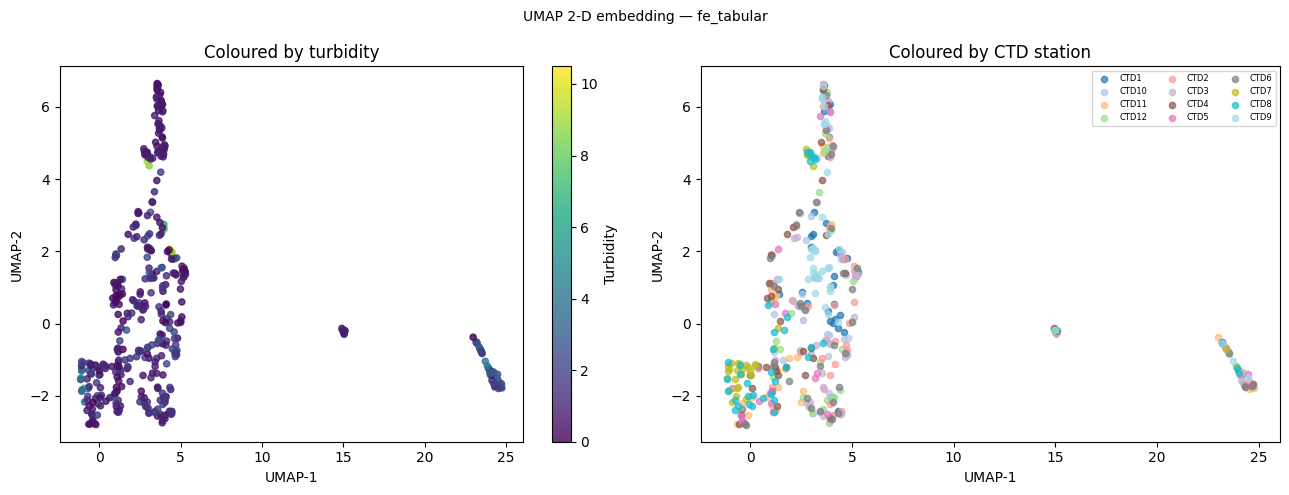

  UMAP-10  fe_tabular  Ridge            RMSE=1.1922  CV_RMSE=0.8780  R²=0.0633
  UMAP-10  fe_tabular  RandomForest     RMSE=1.1074  CV_RMSE=0.8206  R²=0.1776


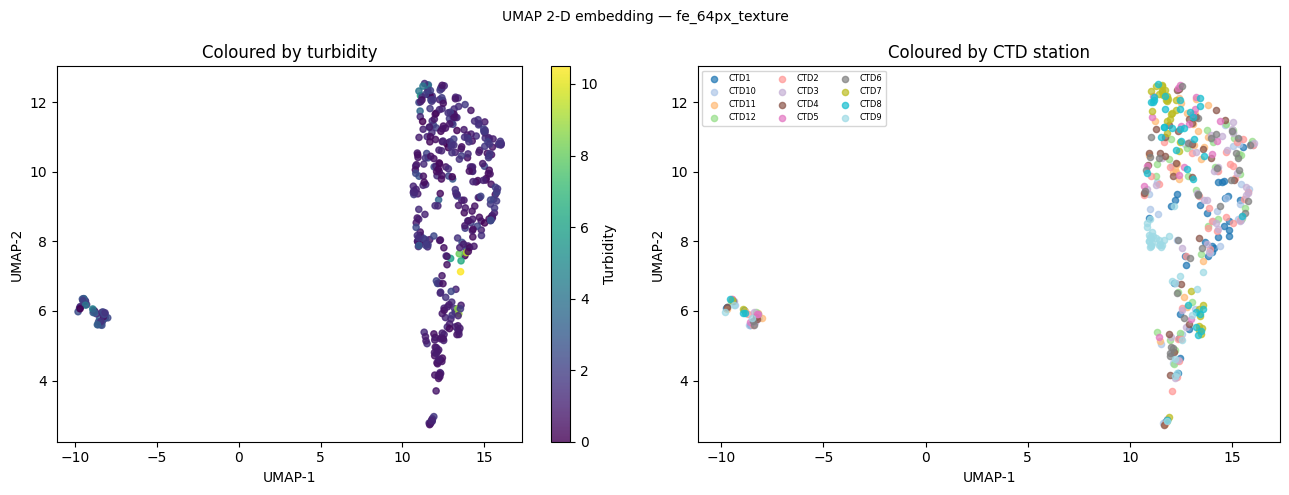

  UMAP-10  fe_64px_texture  Ridge            RMSE=1.2117  CV_RMSE=0.8679  R²=0.0164
  UMAP-10  fe_64px_texture  RandomForest     RMSE=1.1632  CV_RMSE=0.8314  R²=0.1014


In [9]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed. Run: pip install umap-learn")

UMAP_DATASETS = ["fe_tabular", "fe_64px_texture"]

if HAS_UMAP:
    for ds_name in UMAP_DATASETS:
        if ds_name not in datasets:
            continue
        X, y, groups, _ = get_Xy(datasets[ds_name])

        # ── 2-D visualisation ────────────────────────────────────────────────
        reducer2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                              random_state=42)
        Z2 = reducer2.fit_transform(X)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f"UMAP 2-D embedding — {ds_name}", fontsize=10)

        sc = axes[0].scatter(Z2[:, 0], Z2[:, 1], c=y, cmap="viridis", s=20, alpha=0.8)
        plt.colorbar(sc, ax=axes[0], label="Turbidity")
        axes[0].set_title("Coloured by turbidity"); axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")

        ctd_labels = np.unique(groups)
        cmap_ctd   = cm.get_cmap("tab20", len(ctd_labels))
        for k, ctd_id in enumerate(ctd_labels):
            mask = groups == ctd_id
            axes[1].scatter(Z2[mask, 0], Z2[mask, 1], s=20, alpha=0.7,
                             color=cmap_ctd(k), label=ctd_id)
        axes[1].set_title("Coloured by CTD station"); axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
        axes[1].legend(fontsize=6, ncol=3, loc="best")
        plt.tight_layout(); plt.show()

        # ── 10-D regression ──────────────────────────────────────────────────
        reducer10 = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                               random_state=42)
        Z10 = reducer10.fit_transform(X)
        Z10 = StandardScaler().fit_transform(Z10)

        for model_name, model in MODELS.items():
            rmse, cv_rmse, mae, r2 = cv_scores(Z10, y, groups, clone(model))
            print(f"  UMAP-10  {ds_name}  {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  R²={r2:.4f}")
            all_results.append({
                "method": "UMAP-10",
                "dataset": ds_name, "model": model_name,
                "n_components": 10,
                "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
            })

---
## 8 · Autoencoder-Based Dimensionality Reduction

A shallow MLP autoencoder (encoder → bottleneck → decoder) trained with MSE reconstruction
loss. The encoder output is used as the reduced feature vector for Ridge regression.

Architecture: `input → 64 → 32 → bottleneck_dim → 32 → 64 → input`  
Bottleneck sweep: `[4, 8, 16, 32]`

Training autoencoders on fe_64px_texture  (input_dim=69)
  bottleneck= 4  AE RMSE=1.2304  PCA RMSE=1.2121
  bottleneck= 8  AE RMSE=1.2231  PCA RMSE=1.2086
  bottleneck=16  AE RMSE=1.1755  PCA RMSE=1.1954


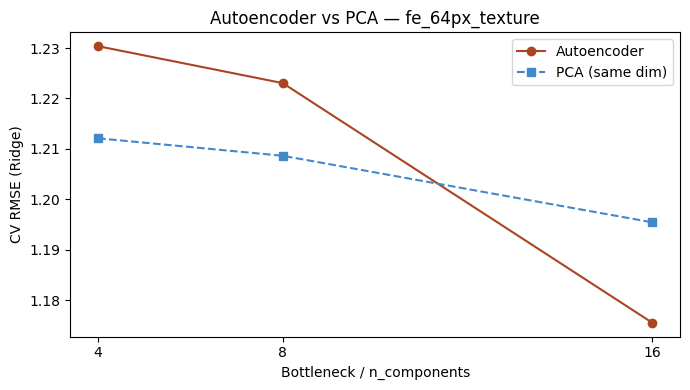

In [10]:
try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("PyTorch not installed. Run: pip install torch")

AE_DS   = "fe_64px_texture"
AE_DIMS = [4, 8, 16]  # capped: N=21, max n_components < min(N, features)
AE_EPOCHS = 200
AE_LR     = 1e-3
AE_BATCH  = 32

class Autoencoder(nn.Module):
    def __init__(self, input_dim: int, bottleneck_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),       nn.ReLU(),
            nn.Linear(32, bottleneck_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32), nn.ReLU(),
            nn.Linear(32, 64),             nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


def train_autoencoder(X_np: np.ndarray, bottleneck_dim: int,
                      epochs: int = AE_EPOCHS, lr: float = AE_LR,
                      batch_size: int = AE_BATCH) -> np.ndarray:
    """Train AE and return encoder output (N, bottleneck_dim)."""
    if not HAS_TORCH:
        return None
    X_t = torch.tensor(X_np, dtype=torch.float32)
    ae  = Autoencoder(X_np.shape[1], bottleneck_dim)
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    dataset  = torch.utils.data.TensorDataset(X_t)
    loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    ae.train()
    for epoch in range(epochs):
        for (batch,) in loader:
            opt.zero_grad()
            loss_fn(ae(batch), batch).backward()
            opt.step()
    ae.eval()
    with torch.no_grad():
        Z = ae.encode(X_t).numpy()
    return Z


if HAS_TORCH and AE_DS in datasets:
    X, y, groups, _ = get_Xy(datasets[AE_DS])
    print(f"Training autoencoders on {AE_DS}  (input_dim={X.shape[1]})")

    ae_rmse_ridge = []
    ae_rmse_pca   = []

    for dim in AE_DIMS:
        # Autoencoder
        Z_ae = train_autoencoder(X, dim)
        Z_ae = StandardScaler().fit_transform(Z_ae)
        rmse_ae, cv_rmse_ae, mae_ae, r2_ae = cv_scores(Z_ae, y, groups, clone(MODELS["Ridge"]))
        ae_rmse_ridge.append(rmse_ae)
        all_results.append({
            "method": "Autoencoder",
            "dataset": AE_DS, "model": "Ridge",
            "n_components": dim,
            "RMSE": rmse_ae, "CV_RMSE": cv_rmse_ae, "MAE": mae_ae, "R2": r2_ae,
        })
        # Reference: PCA at same dimensionality
        Z_pca = PCA(n_components=dim, random_state=42).fit_transform(X)
        Z_pca = StandardScaler().fit_transform(Z_pca)
        rmse_pca, cv_rmse_pca, _, _ = cv_scores(Z_pca, y, groups, clone(MODELS["Ridge"]))
        ae_rmse_pca.append(rmse_pca)
        print(f"  bottleneck={dim:2d}  AE RMSE={rmse_ae:.4f}  PCA RMSE={rmse_pca:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(AE_DIMS, ae_rmse_ridge, marker="o", label="Autoencoder", color="#aa4422", lw=1.5)
    ax.plot(AE_DIMS, ae_rmse_pca,   marker="s", label="PCA (same dim)", color="#4488cc", lw=1.5, ls="--")
    ax.set_xlabel("Bottleneck / n_components"); ax.set_ylabel("CV RMSE (Ridge)")
    ax.set_title(f"Autoencoder vs PCA — {AE_DS}"); ax.legend(); ax.set_xticks(AE_DIMS)
    plt.tight_layout(); plt.show()
elif not HAS_TORCH:
    print("Skipping autoencoder section — PyTorch not available.")

---
## 9 · Recursive Feature Elimination (RFECV)

RFECV wraps a Random Forest estimator and uses GroupKFold cross-validation to find the
optimal number of features by backward elimination. This is a *wrapper* method — it
evaluates subsets using the actual model's performance rather than a proxy statistic.


fe_tabular: optimal features = 35 / 45
  Selected: ['coastal_mean', 'coastal_std', 'coastal_p10', 'blue_std', 'blue_p90', 'green_i_mean', 'green_i_std', 'green_i_p10', 'green_i_p90', 'green_mean', 'green_median', 'green_std', 'green_p10', 'green_p90', 'yellow_median', 'yellow_std', 'yellow_p10', 'yellow_p90', 'red_mean', 'red_std', 'red_p10', 'red_edge_mean', 'red_edge_median', 'red_edge_std', 'red_edge_p10', 'red_edge_p90', 'nir_median', 'nir_std', 'nir_p10', 'nir_p90', 'ndti', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx']


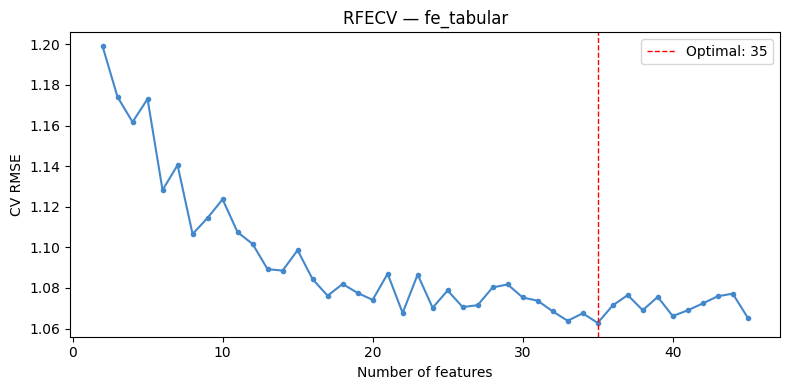

  Ridge            RMSE=1.1902  CV_RMSE=0.8773  MAE=0.6980  R²=0.0648
  RandomForest     RMSE=1.0684  CV_RMSE=0.7936  MAE=0.6437  R²=0.2287

fe_64px_texture: optimal features = 40 / 69
  Selected: ['coastal_p10', 'green_i_median', 'green_i_std', 'green_i_p10', 'green_i_p90', 'green_mean', 'green_std', 'green_p10', 'yellow_std', 'yellow_p10', 'yellow_p90', 'red_mean', 'red_p10', 'red_edge_p10', 'red_edge_p90', 'nir_median', 'nir_std', 'nir_p90', 'ndti', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx', 'coastal_cv', 'coastal_grad_mean', 'coastal_laplace_std', 'blue_cv', 'blue_grad_mean', 'blue_laplace_std', 'green_i_cv', 'green_cv', 'green_laplace_std', 'yellow_cv', 'red_cv', 'red_laplace_std', 'red_edge_cv', 'red_edge_grad_mean', 'nir_cv', 'nir_grad_mean', 'nir_laplace_std']


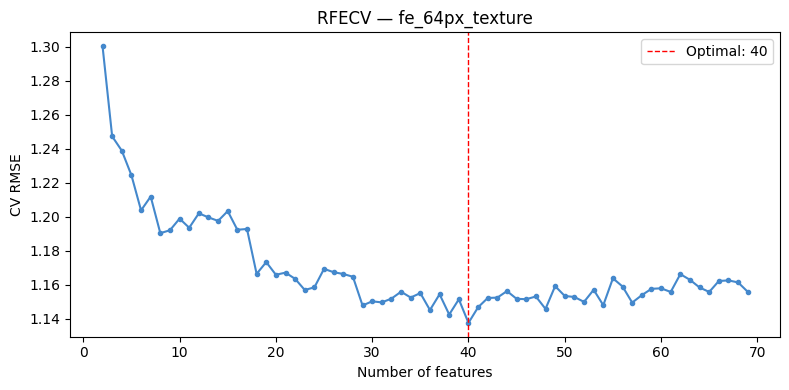

  Ridge            RMSE=1.1994  CV_RMSE=0.8613  MAE=0.7224  R²=0.0260
  RandomForest     RMSE=1.1416  CV_RMSE=0.8212  MAE=0.7000  R²=0.1134


In [11]:
from sklearn.feature_selection import RFECV

RFE_DATASETS = ["fe_tabular", "fe_64px_texture"]

for ds_name in RFE_DATASETS:
    if ds_name not in datasets:
        continue
    X, y, groups, feat_names = get_Xy(datasets[ds_name])
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

    estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rfecv = RFECV(
        estimator=estimator,
        step=1,
        cv=gkf,
        scoring="neg_mean_squared_error",
        min_features_to_select=2,
        n_jobs=-1,
    )
    rfecv.fit(X, y, groups=groups)

    n_selected = rfecv.n_features_
    selected_names = [feat_names[i] for i in range(len(feat_names)) if rfecv.support_[i]]

    print(f"\n{ds_name}: optimal features = {n_selected} / {X.shape[1]}")
    print("  Selected:", selected_names)

    # Plot RMSE vs n_features
    mean_scores = np.sqrt(-rfecv.cv_results_["mean_test_score"])
    n_range     = range(rfecv.min_features_to_select,
                        rfecv.min_features_to_select + len(mean_scores))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(n_range, mean_scores, lw=1.5, color="#4488cc", marker="o", ms=3)
    ax.axvline(n_selected, color="red", ls="--", lw=1, label=f"Optimal: {n_selected}")
    ax.set_xlabel("Number of features"); ax.set_ylabel("CV RMSE")
    ax.set_title(f"RFECV — {ds_name}"); ax.legend()
    plt.tight_layout(); plt.show()

    # Evaluate selected subset
    X_rfe = X[:, rfecv.support_]
    for model_name, model in MODELS.items():
        rmse, cv_rmse, mae, r2 = cv_scores(X_rfe, y, groups, clone(model))
        print(f"  {model_name:15s}  RMSE={rmse:.4f}  CV_RMSE={cv_rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
        all_results.append({
            "method": "RFECV",
            "dataset": ds_name, "model": model_name,
            "n_components": n_selected,
            "RMSE": rmse, "CV_RMSE": cv_rmse, "MAE": mae, "R2": r2,
        })

---
## 10 · Full Comparison: All Methods vs. Model Accuracy

Aggregated summary of RMSE, MAE, R² across all dimensionality reduction methods and models.
Includes bar charts per model and a compression–accuracy scatter (n_features vs. RMSE) to
identify Pareto-optimal methods.

In [12]:
results_df = pd.DataFrame(all_results).dropna(subset=["RMSE"])
results_df = results_df.sort_values("RMSE")

print(f"Total recorded results: {len(results_df)}")
results_df

Total recorded results: 79


,method,dataset,model,n_components,RMSE,CV_RMSE,MAE,R2
1,Baseline,fe_tabular,RandomForest,45,1.061481,0.788708,0.642059,0.237501
76,RFECV,fe_tabular,RandomForest,35,1.068410,0.793590,0.643657,0.228679
39,TruncatedSVD,fe_128px_texture,RandomForest,10,1.104397,0.788919,0.662310,0.187358
69,UMAP-10,fe_tabular,RandomForest,10,1.107388,0.820603,0.689165,0.177638
21,PCA,fe_64px_texture,RandomForest,15,1.120214,0.808434,NaN,NaN
...,...,...,...,...,...,...,...,...
36,IncrementalPCA,fe_128px_texture,Ridge,30,1.309743,0.947863,0.768527,-0.223324
42,TruncatedSVD,fe_128px_texture,Ridge,30,1.312754,0.950792,0.769811,-0.235604
54,TruncatedSVD,fe_256px_texture,Ridge,30,1.314280,0.960150,0.780906,-0.317124
48,IncrementalPCA,fe_256px_texture,Ridge,30,1.319859,0.963905,0.794774,-0.323484


In [13]:

# ── Detailed CV RMSE comparison table ────────────────────────────────────────
print("\n" + "="*90)
print("DETAILED CV RMSE COMPARISON ACROSS ALL METHODS AND MODELS")
print("(CV_RMSE = RMSE / mean(y_test) — normalized root mean square error)")
print("="*90 + "\n")

cv_rmse_summary = (
    results_df
    .groupby(["method", "model"])
    .agg(
        CV_RMSE_best   = ("CV_RMSE", "min"),
        CV_RMSE_mean   = ("CV_RMSE", "mean"),
        CV_RMSE_max    = ("CV_RMSE", "max"),
        CV_RMSE_std    = ("CV_RMSE", "std"),
        RMSE_best      = ("RMSE", "min"),
        RMSE_mean      = ("RMSE", "mean"),
        n_configs      = ("RMSE", "count"),
        MAE_mean       = ("MAE",  "mean"),
        R2_mean        = ("R2",   "mean"),
    )
    .reset_index()
    .round(4)
    .sort_values("CV_RMSE_best")
)

print("Ranked by Best (Min) CV_RMSE:")
print(cv_rmse_summary.to_string(index=False))
print()

# ── Per-dataset breakdown ────────────────────────────────────────────────────
print("\n" + "-"*90)
print("CV_RMSE BREAKDOWN BY DATASET")
print("-"*90 + "\n")

for method in sorted(results_df["method"].unique()):
    print(f"\n{method}:")
    method_data = results_df[results_df["method"] == method].groupby(["dataset", "model"])["CV_RMSE"].agg(["min", "mean", "std", "count"]).round(4)
    print(method_data)



DETAILED CV RMSE COMPARISON ACROSS ALL METHODS AND MODELS
(CV_RMSE = RMSE / mean(y_test) — normalized root mean square error)

Ranked by Best (Min) CV_RMSE:
                 method        model  CV_RMSE_best  CV_RMSE_mean  CV_RMSE_max  CV_RMSE_std  RMSE_best  RMSE_mean  n_configs  MAE_mean  R2_mean
               Baseline RandomForest        0.7887        0.8066       0.8245       0.0253     1.0615     1.1035          2    0.6742   0.1712
           TruncatedSVD RandomForest        0.7889        0.8201       0.8535       0.0190     1.1044     1.1408          9    0.6867   0.1150
                  RFECV RandomForest        0.7936        0.8074       0.8212       0.0195     1.0684     1.1050          2    0.6718   0.1710
         IncrementalPCA RandomForest        0.8049        0.8229       0.8591       0.0177     1.1252     1.1449          9    0.6891   0.1088
                    PCA RandomForest        0.8084        0.8380       0.9147       0.0331     1.1202     1.1650          8    

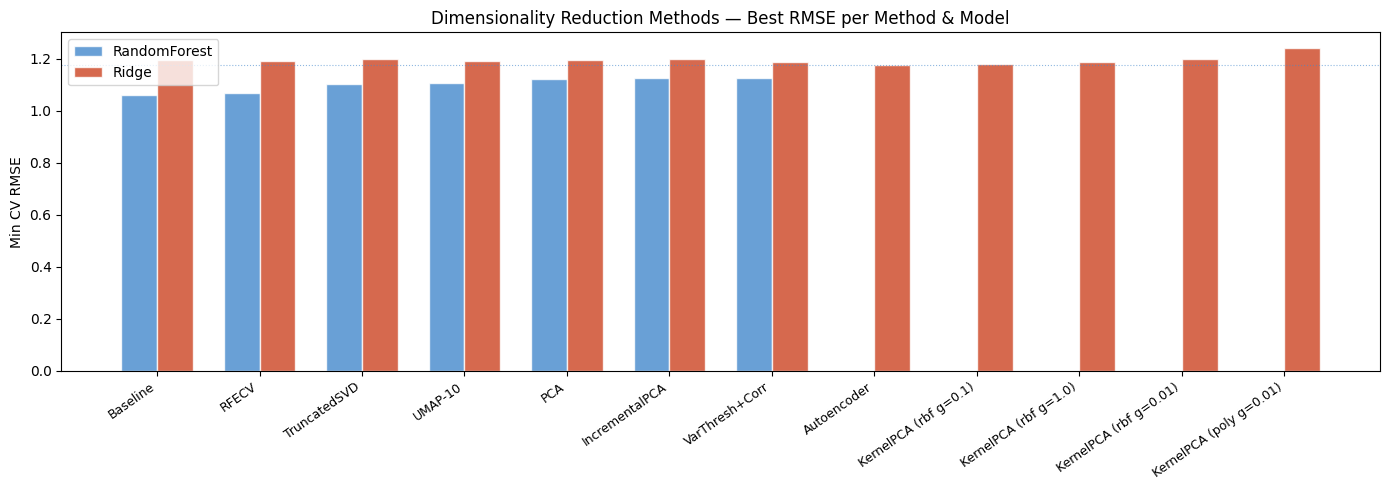

In [14]:
# ── Bar chart: best RMSE per method × model, aggregated over datasets ──────
agg = (
    results_df
    .groupby(["method", "model"])["RMSE"]
    .min()
    .reset_index()
    .sort_values("RMSE")
)

methods = agg["method"].unique()
models  = agg["model"].unique()
x       = np.arange(len(methods))
width   = 0.35
colors  = ["#4488cc", "#cc4422"]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (model_name, color) in enumerate(zip(models, colors)):
    subset = agg[agg["model"] == model_name].set_index("method").reindex(methods)
    ax.bar(x + i * width, subset["RMSE"], width, label=model_name,
           color=color, alpha=0.8, edgecolor="white")

ax.set_xticks(x + width / 2)
ax.set_xticklabels(methods, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Min CV RMSE")
ax.set_title("Dimensionality Reduction Methods — Best RMSE per Method & Model")
ax.legend()
ax.axhline(agg[agg["model"] == "Ridge"]["RMSE"].min(), color="#4488cc",
           lw=0.8, ls=":", alpha=0.6, label="Ridge best")
plt.tight_layout(); plt.show()

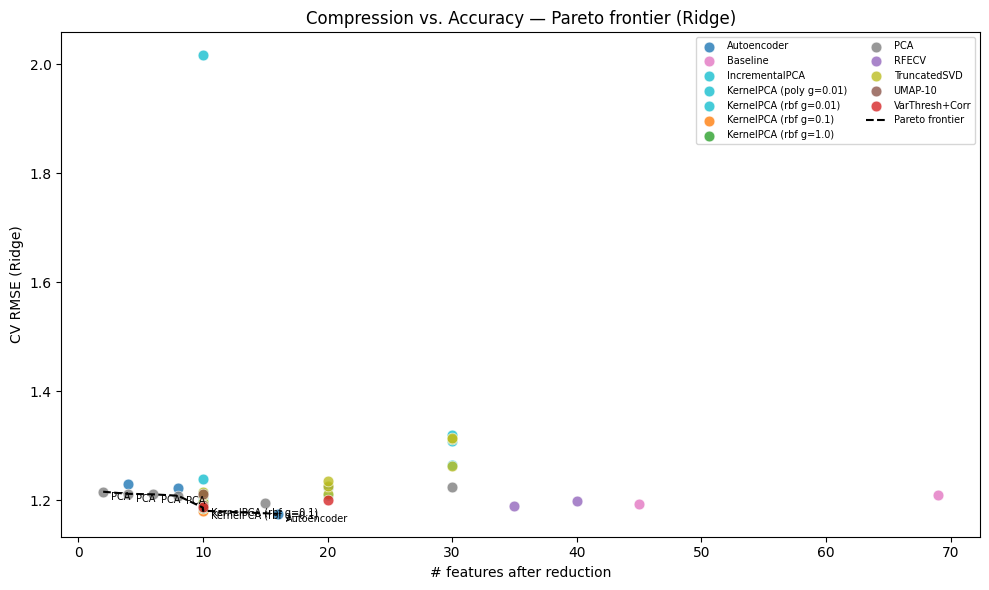

In [15]:
# ── Compression–accuracy scatter (Pareto frontier) ──────────────────────────
# Use Ridge results only for a clean comparison
ridge_df = results_df[results_df["model"] == "Ridge"].copy()
ridge_df = ridge_df.dropna(subset=["n_components", "RMSE"])

fig, ax = plt.subplots(figsize=(10, 6))

method_colors = {m: plt.cm.tab10(i) for i, m in enumerate(ridge_df["method"].unique())}
for method, grp in ridge_df.groupby("method"):
    ax.scatter(grp["n_components"], grp["RMSE"],
               label=method, color=method_colors[method],
               s=60, alpha=0.8, edgecolors="white", lw=0.5)

# Pareto frontier (minimise RMSE for each compression level)
pareto = ridge_df.sort_values("n_components")
pareto_pts = []
best_rmse  = np.inf
for _, row in pareto.iterrows():
    if row["RMSE"] < best_rmse:
        best_rmse = row["RMSE"]
        pareto_pts.append((row["n_components"], row["RMSE"], row["method"]))

if pareto_pts:
    px_ = [p[0] for p in pareto_pts]
    py_ = [p[1] for p in pareto_pts]
    ax.plot(px_, py_, color="black", lw=1.5, ls="--", zorder=10, label="Pareto frontier")
    for px_i, py_i, pm_i in pareto_pts:
        ax.annotate(pm_i, (px_i, py_i), textcoords="offset points",
                    xytext=(6, -6), fontsize=7, color="black")

ax.set_xlabel("# features after reduction")
ax.set_ylabel("CV RMSE (Ridge)")
ax.set_title("Compression vs. Accuracy — Pareto frontier (Ridge)")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

In [16]:
# ── Final summary table ─────────────────────────────────────────────────────
summary_table = (
    results_df
    .groupby(["method", "model"])
    .agg(
        best_RMSE      = ("RMSE", "min"),
        mean_RMSE      = ("RMSE", "mean"),
        std_RMSE       = ("RMSE", "std"),
        best_CV_RMSE   = ("CV_RMSE", "min"),
        mean_CV_RMSE   = ("CV_RMSE", "mean"),
        std_CV_RMSE    = ("CV_RMSE", "std"),
        best_R2        = ("R2",   "max"),
        best_MAE       = ("MAE",  "min"),
        best_n_comp    = ("n_components", lambda x: x.iloc[x.values.argmin()]),
    )
    .reset_index()
    .sort_values(["model", "best_CV_RMSE"])
)

# Add formatted CV RMSE column (normalized RMSE: RMSE / mean(y_test))
summary_table["CV_RMSE_fmt"] = (
    summary_table["mean_CV_RMSE"].round(4).astype(str) + 
    " ± " + 
    summary_table["std_CV_RMSE"].round(4).astype(str)
)

# Mark Pareto-optimal rows per model (lowest CV_RMSE at any given compression level)
summary_table["pareto_optimal"] = False
for model_name in summary_table["model"].unique():
    subset = summary_table[summary_table["model"] == model_name].sort_values("best_n_comp")
    min_cv_rmse = np.inf
    for idx, row in subset.iterrows():
        if row["best_CV_RMSE"] < min_cv_rmse:
            min_cv_rmse = row["best_CV_RMSE"]
            summary_table.at[idx, "pareto_optimal"] = True

print("Full results summary with CV RMSE (RMSE / mean(y_test) — normalized):")
display_cols = ["method", "model", "CV_RMSE_fmt", "best_RMSE", "best_R2", "best_MAE", "best_n_comp", "pareto_optimal"]
print(summary_table[display_cols].rename(columns={"CV_RMSE_fmt": "CV_RMSE"}).to_string(index=False))

Full results summary with CV RMSE (RMSE / mean(y_test) — normalized):
                 method        model         CV_RMSE  best_RMSE   best_R2  best_MAE  best_n_comp  pareto_optimal
               Baseline RandomForest 0.8066 ± 0.0253   1.061481  0.237501  0.642059           45            True
           TruncatedSVD RandomForest  0.8201 ± 0.019   1.104397  0.187358  0.662310           10            True
                  RFECV RandomForest 0.8074 ± 0.0195   1.068410  0.228679  0.643657           35           False
         IncrementalPCA RandomForest 0.8229 ± 0.0177   1.125161  0.153806  0.660578           10           False
                    PCA RandomForest  0.838 ± 0.0331   1.120214       NaN       NaN            2            True
                UMAP-10 RandomForest  0.826 ± 0.0076   1.107388  0.177638  0.683086           10           False
         VarThresh+Corr RandomForest 0.8429 ± 0.0129   1.126400  0.153333  0.682006           10           False
            Autoencoder   

In [17]:
# ── Save results to CSV ─────────────────────────────────────────────────────
import os

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

out_path = RESULTS_DIR / "05_dimreduction_results.csv"
results_df.to_csv(out_path, index=False)
print(f"Results saved to: {out_path.resolve()}")
print(f"  Shape: {results_df.shape}")
print(results_df[["method", "model", "dataset", "RMSE", "CV_RMSE", "MAE", "R2"]].head(10).to_string(index=False))


Results saved to: /home/aurorax/Git_repos/turbidity_satellite_estimation/results/05_dimreduction_results.csv
  Shape: (79, 8)
        method        model          dataset     RMSE  CV_RMSE      MAE       R2
      Baseline RandomForest       fe_tabular 1.061481 0.788708 0.642059 0.237501
         RFECV RandomForest       fe_tabular 1.068410 0.793590 0.643657 0.228679
  TruncatedSVD RandomForest fe_128px_texture 1.104397 0.788919 0.662310 0.187358
       UMAP-10 RandomForest       fe_tabular 1.107388 0.820603 0.689165 0.177638
           PCA RandomForest  fe_64px_texture 1.120214 0.808434      NaN      NaN
  TruncatedSVD RandomForest fe_256px_texture 1.123789 0.807951 0.695776 0.142483
  TruncatedSVD RandomForest fe_128px_texture 1.124560 0.807019 0.662843 0.147556
IncrementalPCA RandomForest fe_128px_texture 1.125161 0.807464 0.660578 0.146148
IncrementalPCA RandomForest  fe_64px_texture 1.125603 0.813698 0.679077 0.115784
IncrementalPCA RandomForest fe_256px_texture 1.126107 0.808530 0